In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

In [2]:
data = pd.read_csv("../datasets/real_estate_properties_data.csv")
df = data.copy()

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          120 non-null    int64  
 1   date_sold      120 non-null    str    
 2   suburb         120 non-null    str    
 3   num_bath       120 non-null    int64  
 4   num_bed        120 non-null    int64  
 5   num_parking    120 non-null    int64  
 6   property_size  120 non-null    float64
 7   type           120 non-null    str    
 8   source_url     120 non-null    str    
dtypes: float64(1), int64(4), str(4)
memory usage: 20.1 KB


In [4]:
df.drop(columns = "source_url", inplace = True)

In [5]:
df["date_sold"] = pd.to_datetime(
    df["date_sold"],
    format = "mixed"
)

df["day"] = df["date_sold"].dt.day
df["month"] = df["date_sold"].dt.month
df["year"] = df["date_sold"].dt.year

df.drop(columns = "date_sold")

,price,suburb,num_bath,num_bed,num_parking,property_size,type,day,month,year
0,930000,mosman,1,1,1,74.0,Apartment,19,8,2026
1,1600000,mosman,1,2,1,96.0,Apartment,12,8,2026
2,1025000,mosman,1,2,1,102.2,Apartment,3,7,2026
3,1450000,mosman,1,2,1,101.0,Apartment,17,6,2026
4,2380000,mosman,2,3,2,192.0,Townhouse,10,6,2026
...,...,...,...,...,...,...,...,...,...,...
115,1010000,blacktown,1,3,3,556.0,House,25,7,2026
116,992500,blacktown,2,4,1,600.0,House,25,7,2026
117,885000,blacktown,1,3,2,562.0,House,25,7,2026
118,570000,blacktown,2,2,1,101.0,Unit,22,7,2026


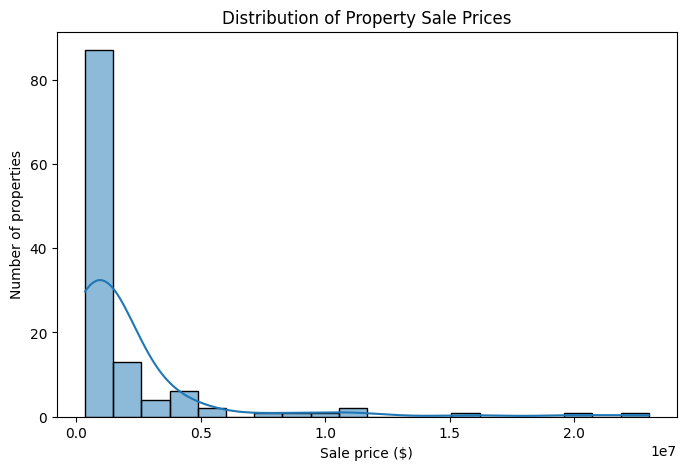

In [6]:
plt.figure(figsize = (8, 5))

sns.histplot(
    data["price"],
    bins = 20,
    kde = True
)

plt.xlabel("Sale price ($)")
plt.ylabel("Number of properties")
plt.title("Distribution of Property Sale Prices")
plt.show()

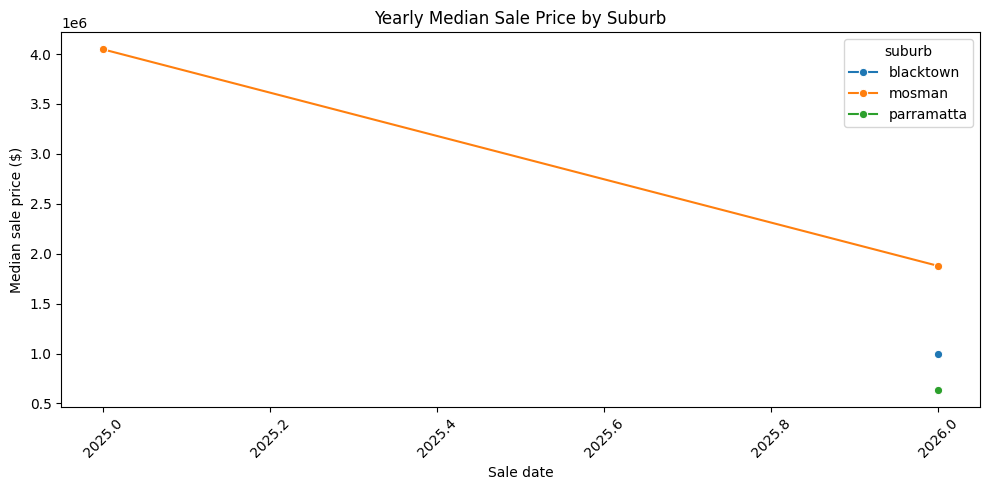

In [7]:
monthly_prices = df.groupby(["suburb", "year"])["price"].median().reset_index()

plt.figure(figsize = (10, 5))

sns.lineplot(
    data = monthly_prices,
    x = "year",
    y = "price",
    hue = "suburb",
    marker = "o"
)

plt.xlabel("Sale date")
plt.ylabel("Median sale price ($)")
plt.title("Yearly Median Sale Price by Suburb")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

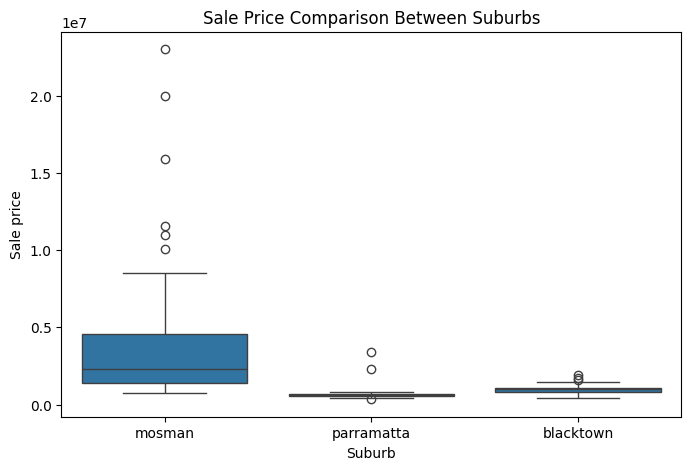

In [8]:
plt.figure(figsize = (8, 5))

sns.boxplot(
    data = df,
    x = "suburb",
    y = "price"
)

plt.xlabel("Suburb")
plt.ylabel("Sale price")
plt.title("Sale Price Comparison Between Suburbs")
plt.show()

In [9]:
suburb_summary = data.groupby("suburb")["price"].agg(
    count = "count",
    mean = "mean",
    median = "median",
    minimum = "min",
    maximum = "max"
)

print(suburb_summary)

            count       mean     median  minimum   maximum
suburb                                                    
blacktown      40   962087.5  1000000.0   410000   1900000
mosman         40  4524975.0  2290000.0   740000  23000000
parramatta     40   731650.0   637500.0   350000   3425000


In [10]:
Q1 = data["price"].quantile(0.25)
Q3 = data["price"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = data[
    (data["price"] < lower_limit) |
    (data["price"] > upper_limit)
]

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Number of potential outliers:", len(outliers))

Lower limit: -798125.0
Upper limit: 3038875.0
Number of potential outliers: 18


In [11]:
outliers[[
    "suburb",
    "type",
    "price",
    "num_bed",
    "num_bath",
    "property_size"
]]

,suburb,type,price,num_bed,num_bath,property_size
5,mosman,House,3390000,4,3,379.0
12,mosman,House,5300000,4,3,613.0
15,mosman,House,23000000,4,3,961.1
16,mosman,House,8500000,4,3,556.4
18,mosman,House,3900000,5,3,624.0
19,mosman,House,7700000,5,5,511.0
21,mosman,House,3750000,3,2,296.0
22,mosman,Apartment,4100000,3,2,172.0
23,mosman,House,3990000,4,2,233.0
27,mosman,House,11550000,7,4,715.0


In [12]:
for col in df.select_dtypes(include = str).columns:
    print(df[col].unique())

<ArrowStringArray>
['mosman', 'parramatta', 'blacktown']
Length: 3, dtype: str
<ArrowStringArray>
[           'Apartment',            'Townhouse',                'House',
                 'Unit', 'Duplex/semi-detached',       'Block of units']
Length: 6, dtype: str


In [13]:
onehotencoder = OneHotEncoder(sparse_output = False)
encoded_cols = onehotencoder.fit_transform(df[df.select_dtypes(include = str).columns].copy())

In [14]:
print(onehotencoder.categories_)

[array(['blacktown', 'mosman', 'parramatta'], dtype=object), array(['Apartment', 'Block of units', 'Duplex/semi-detached', 'House',
       'Townhouse', 'Unit'], dtype=object)]


In [15]:
df[onehotencoder.categories_[0]] = encoded_cols[:, 0:3]
df[onehotencoder.categories_[1]] = encoded_cols[:, 3:]

In [16]:
df.drop(columns = ["date_sold", "suburb", "type"], inplace = True)

In [17]:
df.describe()

,price,num_bath,num_bed,num_parking,property_size,day,month,year,blacktown,mosman,parramatta,Apartment,Block of units,Duplex/semi-detached,House,Townhouse,Unit
count,1.200000e+02,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,2.072904e+06,1.775000,2.816667,1.408333,310.263083,17.266667,7.216667,2025.883333,0.333333,0.333333,0.333333,0.433333,0.008333,0.016667,0.375000,0.033333,0.133333
std,3.495149e+06,1.008056,1.571721,1.072935,270.679487,9.135519,2.253600,0.322369,0.473381,0.473381,0.473381,0.497613,0.091287,0.128556,0.486153,0.180258,0.341360
min,3.500000e+05,1.000000,1.000000,0.000000,37.000000,1.000000,1.000000,2025.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.407500e+05,1.000000,2.000000,1.000000,103.000000,9.000000,7.000000,2026.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.400000e+05,2.000000,2.000000,1.000000,149.500000,19.000000,7.000000,2026.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.600000e+06,2.000000,3.000000,2.000000,560.500000,25.000000,8.000000,2026.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,2.300000e+07,6.000000,12.000000,6.000000,1182.400000,31.000000,12.000000,2026.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: ylabel='property_size'>

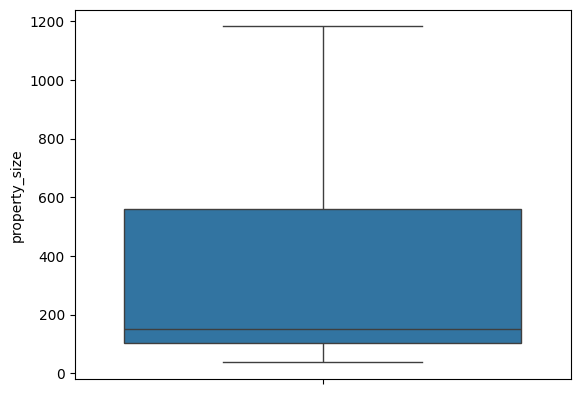

In [18]:
sns.boxplot(
    data = df.property_size.copy()
)

In [19]:
df = df.astype(float)
df.to_csv(
    "../datasets/real_estate_properties_data_cleaned.csv",
    index = False,
    mode = "w"
)